# Homework 2 - MTH 602

William Girard

Due Date: September 30th, 2026

## Floating Point Numbers

### 1. (15 points) Consider an 𝑁-term Taylor series expansion of the exponential function

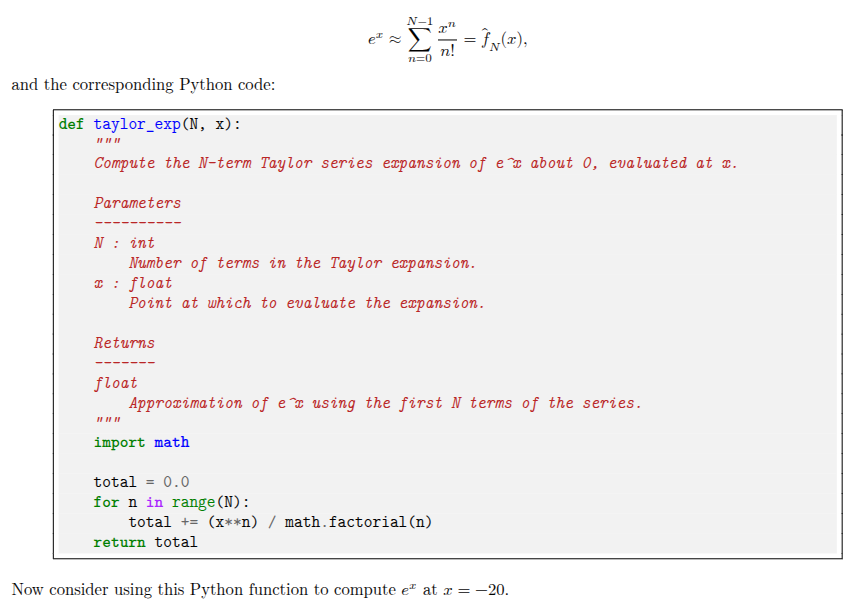

(a) (5 points) Plot the relative error 

\begin{align*}
  E_N = \frac{|\hat{f}_N(-20) - e^{-20}|}{|e^{-20}|}
\end{align*}

as a function of 𝑁 for 𝑁 = 1, 2, ....  What is the smallest relative error you can achieve?  Make the plot using a 
semilog-𝑦 scale.


In [46]:
import math

In [51]:
def taylor_exp(N, x):

    """
    Compute the N-term Taylor series expansion of e^x about 0, evaluated at x.
    
    Parameters
    ----------
    N : int
    Number of terms in the Taylor expansion.
    x : float
    Point at which to evaluate the expansion.

    Returns
    -------
    float
    Approximation of e^x using the first N terms of the series.
    """
 
    total = 0.0
    for n in range(N):
        total += (x**n) / math.factorial(n)

    return total

In [52]:
# experiment with a few large values of N

print(taylor_exp(200, -20))
print(taylor_exp(500, -20))
print(taylor_exp(1000, -20))

5.47810291652921e-10
5.47810291652921e-10
5.47810291652921e-10


In [ ]:
N = 200 # higher N values don't approximate better
error_list = []

for n in range(1, N+1):

    approx = taylor_exp(n, -20)
    true_e = math.exp(-20)
    error = (abs(approx - true_e))/(abs(true_e))
    error_list.append(error)

print(min(error_list))

0.0
1.0
21.0
221.0
1554.3333333333333
8221.0
34887.66666666667
123776.55555555556
377744.8095238095
1012665.4444444445
2423600.1887125224
5245469.677248677
10376141.474587142
18927261.136817917
32082829.847942185
50876499.43526256
75934725.55168974
107257508.19722371
144107840.7213813
185052654.637112
228152458.75893375
271252262.88075554
312299695.37772864
349615543.1022496
382064106.34096354
409104575.70655847
430736951.1990344
447377240.0394005
459703379.9211532
468507765.5509765
474579755.64050984
478627749.0335321
481239357.6741916
482871613.0746038
483860858.7718233
484442768.00548184
484775287.5675724
484960020.65762275
485059876.3819743
485112432.0263698
485139383.6388804
485152859.44513565
485159433.0091626
485162563.27774686
485164019.21662325
485164681.0070216
485164975.13608754
485165103.0182901
485165157.43624866
485165180.11039805
485165189.3651529
485165193.0670548
485165194.51878107
485165195.0771373
485165195.28783774
485165195.36587495
485165195.3942521
485165195.4043

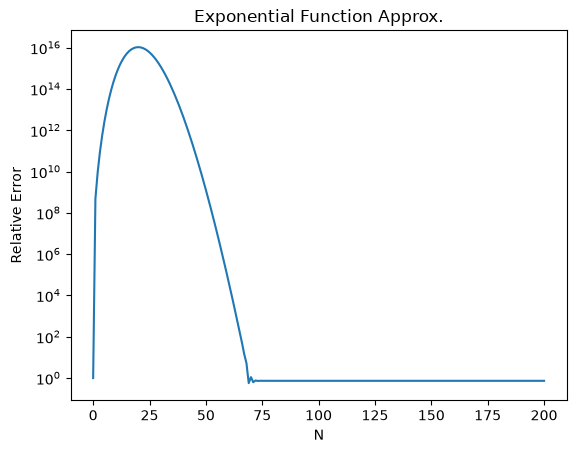

0.5665545568629835


In [36]:
import matplotlib.pyplot as plt

plt.plot(list(range(N+1)), error_list)
plt.semilogy()
plt.title('Exponential Function Approx.')
plt.xlabel('N')
plt.ylabel('Relative Error')
plt.show()

print(min(error_list))

The relative error starts off very high before dropping down and becoming constant. However, the minimum error of 0.5665545568629835 is much much larger than the expected error of $10^{-16}$ , so, clearly something is wrong.

(b) (5 points) You should find the relative error is much larger than the expected value of $\approx 10^{-16}$. Briefly explain the 
numerical reason for this behavior (hint: think about cancellation when 𝑥 is negative and large in magnitude).

In [41]:
# print each term in the taylor series
# will help me answer part B by investigating what the terms are actually evaluating to 

def mod_taylor_exp(N, x):

    """
    Compute the N-term Taylor series expansion of e^x about 0, evaluated at x.
    
    Parameters
    ----------
    N : int
    Number of terms in the Taylor expansion.
    x : float
    Point at which to evaluate the expansion.

    Returns
    -------
    float
    Approximation of e^x using the first N terms of the series.
    """
 
    total = 0.0
    for n in range(N):
        total += (x**n) / math.factorial(n)
        print(f'Current term: {(x**n) / math.factorial(n)} - Running Total: {total}')

    return total

total = mod_taylor_exp(100, -20)
print(f'\nTotal: {total}')

Current term: 1.0 - Running Total: 1.0
Current term: -20.0 - Running Total: -19.0
Current term: 200.0 - Running Total: 181.0
Current term: -1333.3333333333333 - Running Total: -1152.3333333333333
Current term: 6666.666666666667 - Running Total: 5514.333333333334
Current term: -26666.666666666668 - Running Total: -21152.333333333336
Current term: 88888.88888888889 - Running Total: 67736.55555555556
Current term: -253968.25396825396 - Running Total: -186231.6984126984
Current term: 634920.6349206349 - Running Total: 448688.9365079365
Current term: -1410934.7442680777 - Running Total: -962245.8077601411
Current term: 2821869.4885361553 - Running Total: 1859623.6807760142
Current term: -5130671.797338464 - Running Total: -3271048.1165624503
Current term: 8551119.662230773 - Running Total: 5280071.545668323
Current term: -13155568.711124267 - Running Total: -7875497.165455945
Current term: 18793669.58732038 - Running Total: 10918172.421864435
Current term: -25058226.116427176 - Running Tota

In [55]:
N = 200 # higher N values don't approximate better
error_list = []

for n in range(1, N+1):

    approx_pos = taylor_exp(n, 20)
    approx = 1/approx_pos
    true_e = math.exp(-20)
    error = (abs(approx - true_e))/(abs(true_e))
    error_list.append(error)

print(min(error_list))

2.0065962176423985e-16
